### Import


In [266]:
# %% Import and data
import mrpro
from mrpro.data import SpatialDimension
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mrpro.algorithms.reconstruction.DirectReconstruction import DirectReconstruction
from mrpro.data._kdata.KData import KData  # Import the KData class
from mrpro.data.KTrajectory import KTrajectory
from mrpro.data.traj_calculators.KTrajectoryPulseq import KTrajectoryPulseq
from mrpro.operators.FourierOp import FourierOp
from mrpro.phantoms.EllipsePhantom import EllipsePhantom  # Adjust the import path as needed
from mrpro.phantoms.phantom_elements import EllipseParameters
from mrpro.operators.DensityCompensationOp import DensityCompensationOp
from einops import rearrange
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Base path for data files
base_path = '/home/bouill01/data/20240319_spiral_2D_256mm_220k0_128interleaves_golden_angle_vds/'

# Use the trajectory that is stored in the ISMRMRD file
# Load data from Pulseq file using KTrajectoryPulseq
h5_path = base_path + 'pulseq_spiral_2D_220k0_128interleaves_golden_angle_vds_with_traj.h5'
seq_path = base_path + '20240319_spiral_2D_256mm_220k0_128interleaves_golden_angle_vds.seq'

kdatapuls = KData.from_file(h5_path, KTrajectoryPulseq(seq_path=seq_path))

### Flags

In [267]:
FLAG_UNET = True  # If True, the convolutional neural network will be configured as a U-Net.
FLAG_single_image = False # Set to True for training with only one image, False to generate a new image each iteration

## Function Definition

### visualize_results function

In [268]:
def visualize_results(epoch, iteration, xu, xf, xreco):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(torch.abs(xu).squeeze().cpu().numpy(), cmap='gray', clim=[0,100])
    plt.colorbar()
    plt.title('Input Undersampled Image')
    plt.subplot(1, 3, 2)
    plt.imshow(torch.abs(xf).squeeze().cpu().numpy(), cmap='gray', clim=[0,100])
    plt.colorbar()
    plt.title('Full-sampled Image')
    plt.subplot(1, 3, 3)
    plt.imshow(torch.abs(xreco).squeeze().cpu().detach().numpy(), cmap='gray', clim=[0,100])
    plt.colorbar()
    plt.title('Reconstructed Image')
    plt.suptitle(f'Epoch {epoch+1}, Iteration {iteration+1}')
    plt.show()

In [269]:
# Function to calculate SSIM and PSNR
def calculate_metrics(img1, img2):
    img1_np = img1.abs().detach().squeeze().numpy()
    img2_np = img2.abs().detach().squeeze().numpy()
    
    ssim_value = ssim(img1_np, img2_np, data_range=img2_np.max() - img2_np.min())
    psnr_value = psnr(img1_np, img2_np, data_range=img2_np.max() - img2_np.min())
    
    return ssim_value, psnr_value

# Function to plot images with SSIM and PSNR
def plot_images(images_reco, images_us, images_fs, indice):
    # Calculate SSIM and PSNR for reconstructed and undersampled images
    ssim_reco, psnr_reco = calculate_metrics(images_fs[indice], images_reco[indice])
    ssim_us, psnr_us = calculate_metrics(images_fs[indice], images_us[indice])

    plt.figure(figsize=(15, 5))

    # Reconstructed Image
    plt.subplot(1, 3, 1)
    plt.imshow(torch.abs(images_reco[indice]).detach().squeeze().numpy(), cmap='gray', clim=[0,100])
    plt.title(f'Reconstructed - Image {indice+1}\nSSIM: {ssim_reco:.4f}, PSNR: {psnr_reco:.2f} dB')
    plt.axis('off')

    # Undersampled Image
    plt.subplot(1, 3, 2)
    plt.imshow(torch.abs(images_us[indice]).detach().squeeze().numpy(), cmap='gray', clim=[0,100])
    plt.title(f'Undersampled - Image {indice+1}\nSSIM: {ssim_us:.4f}, PSNR: {psnr_us:.2f} dB')
    plt.axis('off')
    
    # Fully Sampled Image
    plt.subplot(1, 3, 3)
    plt.imshow(torch.abs(images_fs[indice]).detach().squeeze().numpy(), cmap='gray', clim=[0,100])
    plt.title(f'Fully Sampled - Image {indice+1}')
    plt.axis('off')

    plt.show()


### Shifiting function

In [270]:
def shift_k_space_trajectory(kdatapuls: KData) -> KData:
    # Extract k-space trajectory from kdatapuls
    ky_pulseq = kdatapuls.traj.ky
    kx_pulseq = kdatapuls.traj.kx
    kz_pulseq = kdatapuls.traj.kz

    # Number of indices
    num_indices = ky_pulseq.shape[2]

    # Initialize lists to store shifted trajectories
    shifted_ky = ky_pulseq.clone()
    shifted_kx = kx_pulseq.clone()

    # Loop to apply the shift to each index
    for i in range(num_indices - 1):
        # Calculate the shift for the current index
        shifted_ky[:, :, i, :] -= ky_pulseq[:, :, i, 0]
        shifted_kx[:, :, i, :] -= kx_pulseq[:, :, i, 0]

    # Create shifted KTrajectory object
    shifted_traj = KTrajectory(kx=shifted_kx, ky=shifted_ky, kz=kz_pulseq)
    # Create shifted KData object
    shifted_kdatapuls = KData(data=kdatapuls.data, traj=shifted_traj, header=kdatapuls.header)

    return shifted_kdatapuls

In [271]:
shifted_kdatapuls = shift_k_space_trajectory(kdatapuls)

shifted_kdatapuls.header.recon_matrix.x = 256
shifted_kdatapuls.header.recon_matrix.y = 256

### Creating Ellipses function

In [272]:
def generate_random_ellipses(num_ellipses):
    ellipses = []
    for _ in range(num_ellipses):
        # Generate radius first to use it for constraining center coordinates
        radius_x = np.random.uniform(0.05, 0.4)
        radius_y = np.random.uniform(0.05, 0.4)
        
        # Calculate bounds for the center coordinates to keep the ellipse within [-0.5, 0.5] x [-0.5, 0.5]
        min_center_x = -0.4 + radius_x 
        max_center_x = 0.4 - radius_x
        min_center_y = -0.4 + radius_y
        max_center_y = 0.4 - radius_y
        
        center_x = np.random.uniform(min_center_x, max_center_x)
        center_y = np.random.uniform(min_center_y, max_center_y)
        
        intensity = np.random.uniform(1, 50)
        ellipses.append(EllipseParameters(center_x, center_y, radius_x, radius_y, intensity))
    
    return ellipses

## CNN

### ConvBlock

In [273]:
class ConvBlock(nn.Module):
    """
    A simple block of convolutional layers (1D, 2D or 3D)
    """

    def __init__(
        self,
        n_ch_in,
        n_ch_out,
        n_convs,
        kernel_size=3,
        bias=True,
        padding_mode="zeros",
    ):
        super().__init__()

        padding = int(np.floor(kernel_size / 2))

        conv_block_list = []
        conv_block_list.extend(
            [
                nn.Conv2d(
                    n_ch_in,
                    n_ch_out,
                    kernel_size,
                    padding=padding,
                    bias=bias,
                    padding_mode=padding_mode,
                ),
                nn.LeakyReLU(),
            ]
        )

        for i in range(n_convs - 1):
            conv_block_list.extend(
                [
                    nn.Conv2d(
                        n_ch_out,
                        n_ch_out,
                        kernel_size,
                        padding=padding,
                        bias=bias,
                        padding_mode=padding_mode,
                    ),
                    nn.LeakyReLU(),
                ]
            )

        self.conv_block = nn.Sequential(*conv_block_list)

    def forward(self, x):
        return self.conv_block(x)

### Encoder

In [274]:
class Encoder(nn.Module):
    def __init__(
        self,
        n_ch_in,
        n_enc_stages,
        n_convs_per_stage,
        n_filters,
        kernel_size=3,
        bias=True,
        padding_mode="zeros",
    ):
        super().__init__()

        n_ch_list = [n_ch_in]
        for ne in range(n_enc_stages):
            n_ch_list.append(int(n_filters) * 2**ne)

        self.enc_blocks = nn.ModuleList(
            [
                ConvBlock(
                    n_ch_list[i],
                    n_ch_list[i + 1],
                    n_convs_per_stage,
                    kernel_size=kernel_size,
                    bias=bias,
                    padding_mode=padding_mode,
                )
                for i in range(len(n_ch_list) - 1)
            ]
        )

        self.pool = nn.MaxPool2d(2)
        
    def forward(self, x):
        features = []
        for block in self.enc_blocks:
            x = block(x)
            features.append(x)
            x = self.pool(x)
        return features

### Decoder

In [275]:
class Decoder(nn.Module):
    def __init__(
        self,
        n_ch_in,
        n_dec_stages,
        n_convs_per_stage,
        kernel_size=3,
        bias=False,
        padding_mode="zeros",
    ):
        super().__init__()

        n_ch_list = []
        for ne in range(n_dec_stages):
            n_ch_list.append(int(n_ch_in * (1 / 2) ** ne))
            
        self.interp_mode = "bilinear"

        padding = int(np.floor(kernel_size / 2))
        self.upconvs = nn.ModuleList(
            [
                nn.Conv2d(
                    n_ch_list[i],
                    n_ch_list[i + 1],
                    kernel_size=kernel_size,
                    padding=padding,
                    bias=bias,
                    padding_mode=padding_mode,
                )
                for i in range(len(n_ch_list) - 1)
            ]
        )
        self.dec_blocks = nn.ModuleList(
            [
                ConvBlock(
                    n_ch_list[i],
                    n_ch_list[i + 1],
                    n_convs_per_stage,
                    kernel_size=kernel_size,
                    bias=bias,
                    padding_mode=padding_mode,
                )
                for i in range(len(n_ch_list) - 1)
            ]
        )

    def forward(self, x, encoder_features):
        for i in range(len(self.dec_blocks)):
            enc_features = encoder_features[i]
            enc_features_shape = enc_features.shape
            x = nn.functional.interpolate(
                x, enc_features_shape[2:], mode=self.interp_mode, align_corners=False
            )
            x = self.upconvs[i](x)
            x = torch.cat([x, enc_features], dim=1)
            x = self.dec_blocks[i](x)
        return x


### Unet

In [276]:
class UNet(nn.Module):
    def __init__(
        self,
        n_ch_in=2,
        n_ch_out=2,
        n_enc_stages=3,
        n_convs_per_stage=2,
        n_filters=16,
        kernel_size=3,
        bias=True,
        residual_connection=True,
        padding_mode="zeros",
    ):
        super().__init__()
        self.encoder = Encoder(
            n_ch_in,
            n_enc_stages,
            n_convs_per_stage,
            n_filters,
            kernel_size=kernel_size,
            bias=bias,
            padding_mode=padding_mode,
        )
        self.decoder = Decoder(
            n_filters * (2 ** (n_enc_stages - 1)),
            n_enc_stages,
            n_convs_per_stage,
            kernel_size=kernel_size,
            bias=bias,
            padding_mode=padding_mode,
        )

        self.c1x1 = nn.Conv2d(n_filters, n_ch_out, kernel_size=1, padding=0, bias=bias)

        self.residual_connection = residual_connection
        if residual_connection:
            if n_ch_in != n_ch_out:
                raise ValueError(
                    "For using the residual connection, the number of input and output channels of the \
                    network must be the same.\
                    Given {n_ch_in} and {n_ch_out}."
                )

    def forward(self, x):
        enc_features = self.encoder(x)
        dec = self.decoder(enc_features[-1], enc_features[::-1][1:])
        out = self.c1x1(dec)
        if self.residual_connection:
            out = out + x
        return out


## NUFFTCascade

In [281]:
class NUFFTCascade(nn.Module):
    def __init__(
        self,
        operator_norm,
        acquisition_operator: FourierOp,
        factor: float,
        max_iter: int = 10,
        n_filters=64,
        kernel_size=3,
    ) -> None:
        super(NUFFTCascade, self).__init__()
        self.acquisition_operator = acquisition_operator
        self.factor = factor
        self.max_iter = max_iter
        self.operator_norm=operator_norm
        self.unet = UNet(n_ch_in=2, n_ch_out=2, n_enc_stages=3, n_convs_per_stage=2, n_filters=n_filters, bias=False, kernel_size=kernel_size, residual_connection=False)
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels=2, out_channels=64, kernel_size=kernel_size, padding='same', bias=False),
            nn.LeakyReLU(),
            nn.Conv2d(
                in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding='same', bias=False
            ),
            nn.LeakyReLU(),
            nn.Conv2d(
                in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding='same', bias=False
            ),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=n_filters, out_channels=2, kernel_size=kernel_size, padding='same', bias=False),
        )

    def apply_CNN(self, x):
        other, coil, nz, ny, nx = x.shape
        x = rearrange(torch.view_as_real(x), 'other coil z y x ch -> (other coil z) ch y x')

        x = self.cnn(x)

        x = torch.view_as_complex(
            rearrange(
                x,
                '(other coil z) ch y x -> other coil z y x ch',
                other=other,
                coil=coil,
                z=nz,
                y=ny,
                x=nx,
                ch=2,
            ).contiguous()
        )

        return x

    def apply_UNet(self, x):
        other, coil, nz, ny, nx = x.shape
        x = rearrange(torch.view_as_real(x), 'other coil z y x ch -> (other coil z) ch y x')

        x = self.unet(x)

        x = torch.view_as_complex(
            rearrange(
                x,
                '(other coil z) ch y x -> other coil z y x ch',
                other=other,
                coil=coil,
                z=nz,
                y=ny,
                x=nx,
                ch=2,
            ).contiguous()
        )

        return x
    

    def forward(self, x, k_space_data):
        for _ in range(self.max_iter):
            x = x.clone()
            step_size = 2.0 / self.operator_norm**2
            res_acq= self.acquisition_operator.H(self.acquisition_operator(x)[0] - (k_space_data.data))
            
            if FLAG_UNET:
                x = x - self.factor * step_size * res_acq[0] + self.apply_UNet(x) 
            else : 
                x = x - self.factor * step_size * res_acq[0] + self.apply_CNN(x) 
        return x

### Hyperparameters

In [278]:
n_epochs = 10
n_itera = 10
learning_rate = 1e-4
batch_size = 1

lossesssss = []
tot_loss = 0
list_xreco = []
list_xu = []
list_xf = []

model = NUFFTCascade(acquisition_operator=None,operator_norm=None, factor=0.98, max_iter=4)
mse_loss = lambda x: F.mse_loss(torch.view_as_real(x_fullsamp), torch.view_as_real(x))
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

### FLAG_single_image

In [279]:
if FLAG_single_image :
    ellipses = generate_random_ellipses(8)
    phantom = EllipsePhantom(ellipses)

    kspace_data = phantom.kspace(shifted_kdatapuls.traj.ky, shifted_kdatapuls.traj.kx)


    kdata_object = KData(
        data=kspace_data.unsqueeze(0), header=shifted_kdatapuls.header, traj=shifted_kdatapuls.traj
    )

    kdata_us = KData.split_k1_into_other(kdata_object, torch.arange(0, 128, 4)[None, :], other_label='repetition')

    direct_reconstruction_fullsamp = DirectReconstruction.from_kdata(kdata_object)
    x_fullsamp = direct_reconstruction_fullsamp(kdata_object).data
    xf = x_fullsamp.squeeze(0).squeeze(0).squeeze(0)

    direct_reconstruction_us = DirectReconstruction.from_kdata(kdata_us)
    x_us = direct_reconstruction_us(kdata_us).data

    fourier_operator = mrpro.operators.FourierOp.from_kdata(kdata=kdata_us)
    dcf_operator = DensityCompensationOp(2*torch.sqrt(direct_reconstruction_us.dcf.data)) ## 2*torch.sqrt() or not
    acquisition_operator = dcf_operator @ fourier_operator # No need to add csm 
    model.acquisition_operator = acquisition_operator
    
    initial_value = torch.randn(1, 1 , 1, 256, 256, dtype=torch.complex64)
    op_norm_estimate = acquisition_operator.operator_norm(initial_value=initial_value, dim=None)
    model.operator_norm = op_norm_estimate

    kdata = acquisition_operator(x_fullsamp)[0]
    (xu,) = acquisition_operator.H(kdata)             

    kdata_uus = KData(
        data=kdata, header=kdata_us.header, traj=kdata_us.traj
    )

## Training

In [280]:
if FLAG_single_image:
    for epoch in range(n_epochs):
        for i in range (n_itera):
            
            
            optimizer.zero_grad()
            xreco = model(xu, kdata_uus)

            loss = mse_loss(xreco)
            loss.backward()
            optimizer.step()
            print(f'Epoch [{epoch+1}/{n_epochs}], Iteration [{i+1}/{n_itera}], Loss: {loss.item():.4f}')

            tot_loss += loss.item()
                
            if i == (n_itera-1):
                visualize_results(epoch, i, xu, xf, xreco)
                lossesssss.append(tot_loss/n_itera)
                tot_loss = 0
                list_xreco.append(xreco)
                list_xu.append(xu)
                list_xf.append(xf)

else :
    for epoch in range(n_epochs):
        for i in range (n_itera):
            
            ellipses = generate_random_ellipses(8)
            phantom = EllipsePhantom(ellipses)

            kspace_data = phantom.kspace(shifted_kdatapuls.traj.ky, shifted_kdatapuls.traj.kx)


            kdata_object = KData(
                data=kspace_data.unsqueeze(0), header=shifted_kdatapuls.header, traj=shifted_kdatapuls.traj
            )

            kdata_us = KData.split_k1_into_other(kdata_object, torch.arange(0, 128, 4)[None, :], other_label='repetition')

            direct_reconstruction_fullsamp = DirectReconstruction.from_kdata(kdata_object)
            x_fullsamp = direct_reconstruction_fullsamp(kdata_object).data
            xf = x_fullsamp.squeeze(0).squeeze(0).squeeze(0)

            direct_reconstruction_us = DirectReconstruction.from_kdata(kdata_us)
            x_us = direct_reconstruction_us(kdata_us).data
            xxx = x_us.squeeze(0).squeeze(0).squeeze(0)

            fourier_operator = mrpro.operators.FourierOp.from_kdata(kdata=kdata_us)
            dcf_operator = DensityCompensationOp(2*torch.sqrt(direct_reconstruction_us.dcf.data)) 
            acquisition_operator = dcf_operator @ fourier_operator 

            initial_value = torch.randn(1, 1 , 1, 256, 256, dtype=torch.complex64)
            op_norm_estimate = acquisition_operator.operator_norm(initial_value=initial_value, dim=None)


            kdata = acquisition_operator(x_fullsamp)[0]
            (xu,) = acquisition_operator.H(kdata)             

            kdata_uus = KData(
                data=kdata, header=kdata_us.header, traj=kdata_us.traj
            )
            
            optimizer.zero_grad()
            model.acquisition_operator = acquisition_operator
            model.operator_norm = op_norm_estimate
            xreco = model(xu, kdata_uus)

            loss = mse_loss(xreco)
            loss.backward()
            optimizer.step()
            print(f'Epoch [{epoch+1}/{n_epochs}], Iteration [{i+1}/{n_itera}], Loss: {loss.item():.4f}')

            tot_loss += loss.item()
                
            if i == (n_itera-1):
                visualize_results(epoch, i, xu, xf, xreco)
                lossesssss.append(tot_loss/n_itera)
                tot_loss = 0
                list_xreco.append(xreco)
                list_xu.append(xu)
                list_xf.append(xf)

print('Training finished.')
print(f'average losses for each epoch = {lossesssss}')


Epoch [1/10], Iteration [1/10], Loss: 3.3681
Epoch [1/10], Iteration [2/10], Loss: 1.8519
Epoch [1/10], Iteration [3/10], Loss: 5.0014


KeyboardInterrupt: 

### Display

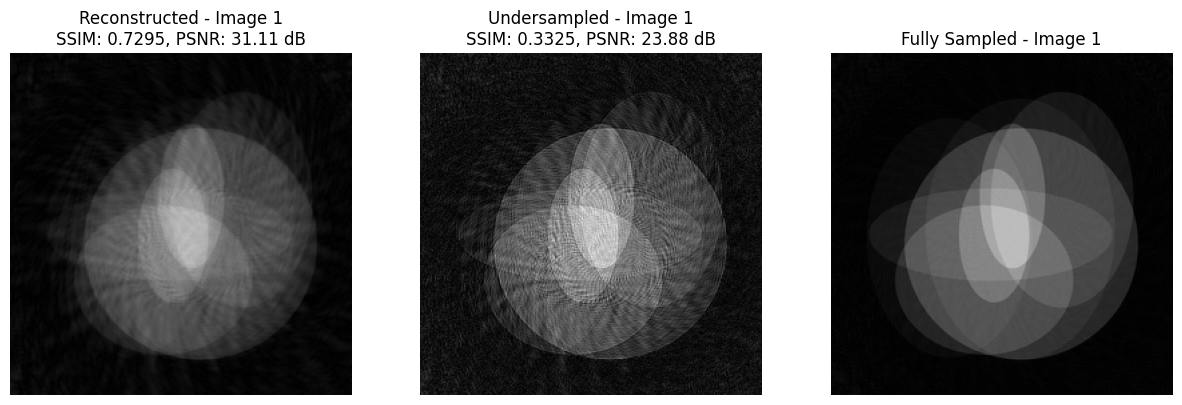

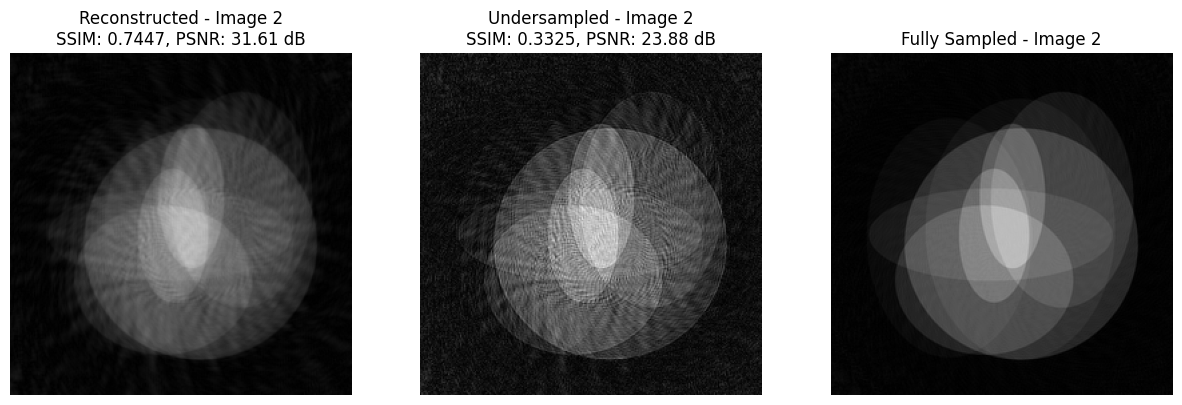

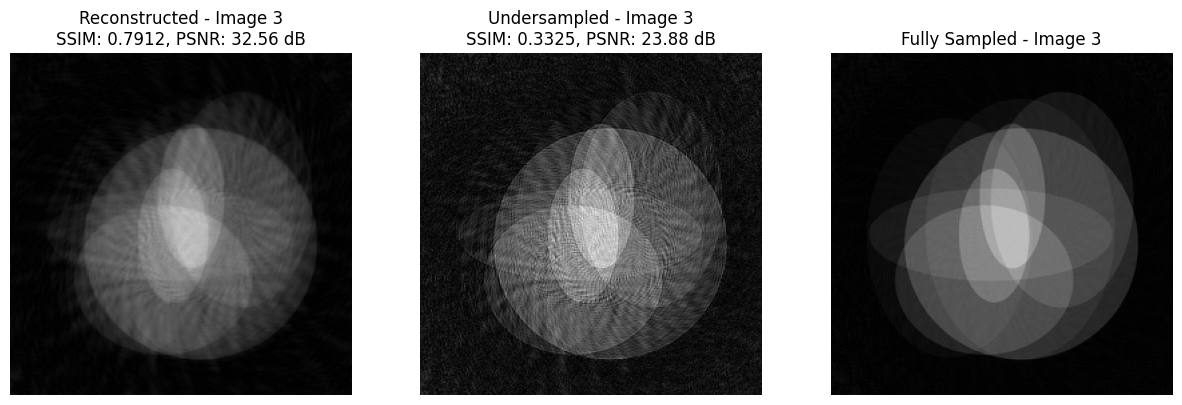

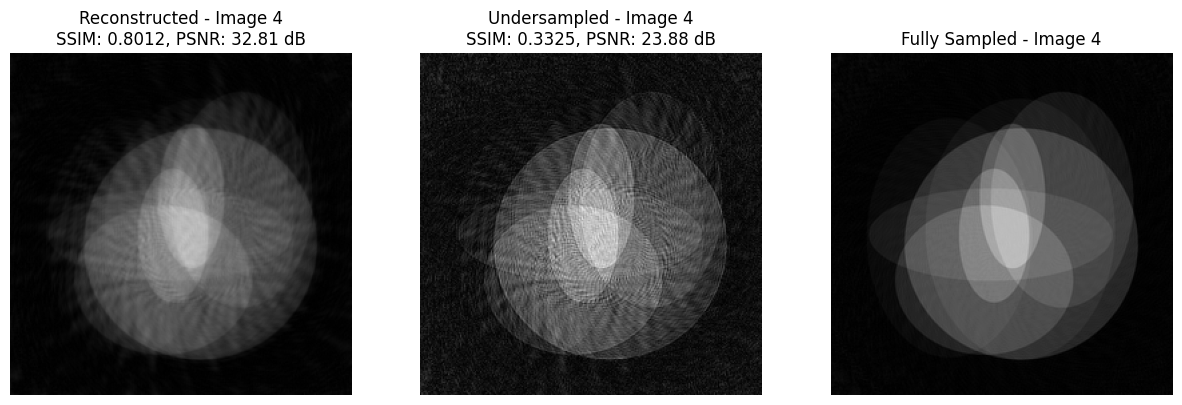

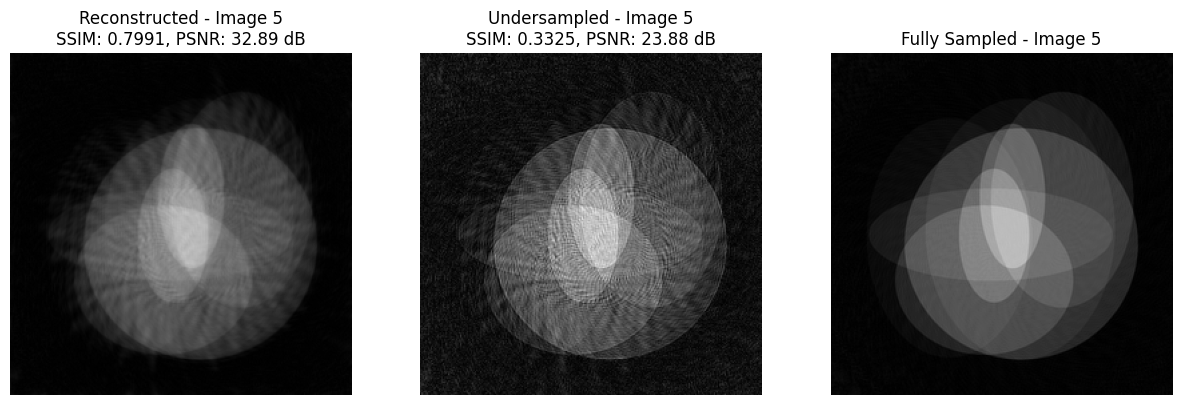

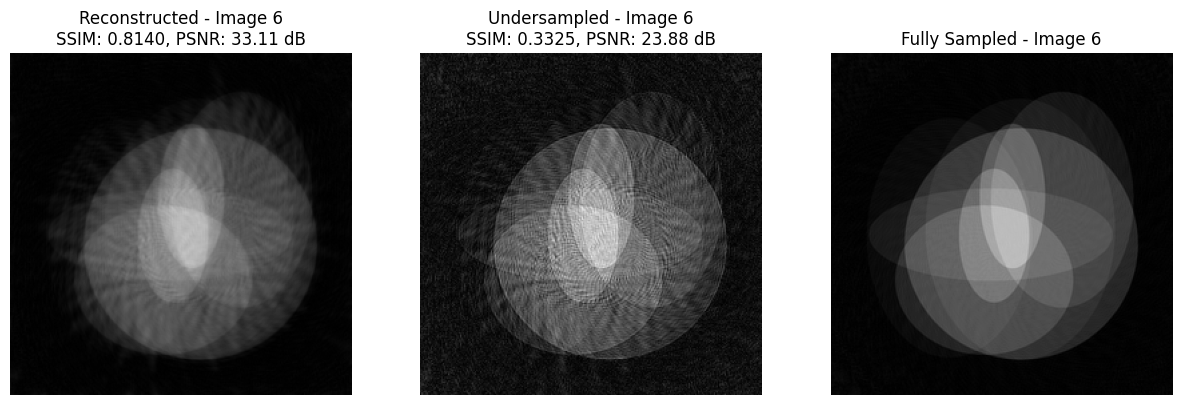

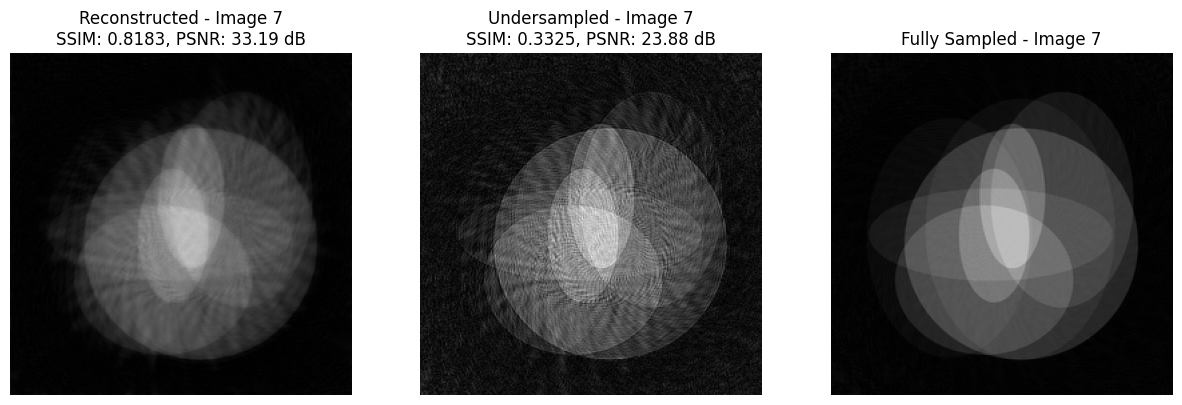

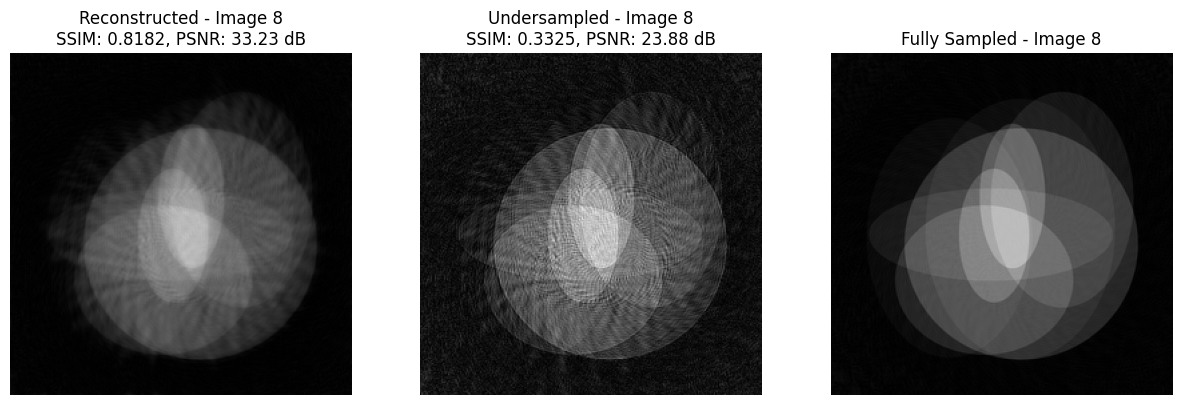

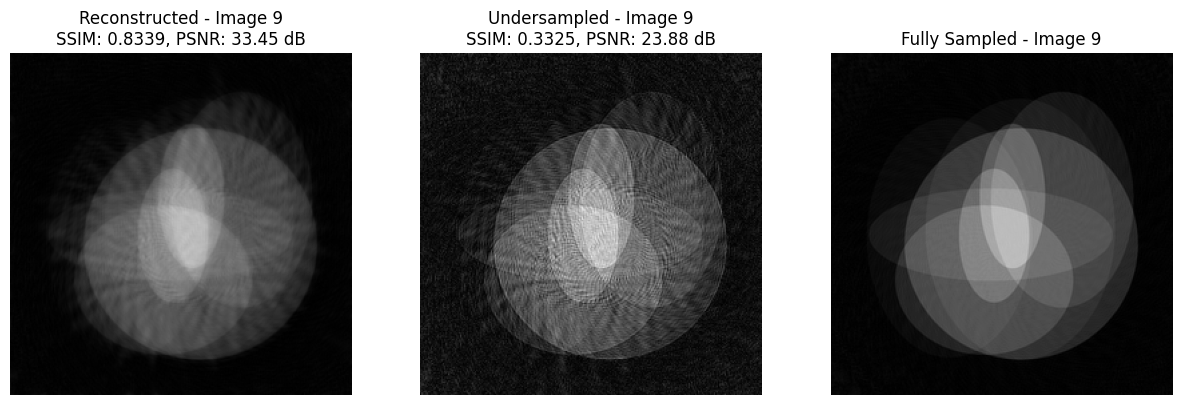

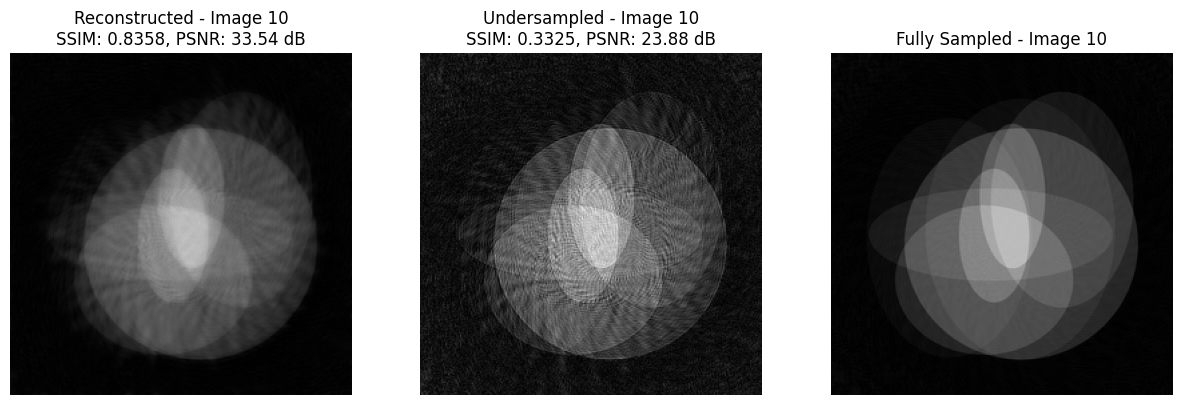

In [ ]:
for i in range (len(list_xu)):
    plot_images(list_xreco, list_xu, list_xf,i)